<a href="https://colab.research.google.com/github/aditi1295/MachineLearning/blob/main/bagging_learning_tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import numpy as np
import pandas as pd

In [43]:
df = pd.read_csv('/content/iris.csv')

In [44]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [45]:

df = df.iloc[:,1:]

In [46]:

df.head()

,sepal_width,petal_length,petal_width,species
0,3.5,1.4,0.2,setosa
1,3.0,1.4,0.2,setosa
2,3.2,1.3,0.2,setosa
3,3.1,1.5,0.2,setosa
4,3.6,1.4,0.2,setosa


In [47]:
from sklearn.preprocessing import LabelEncoder

In [48]:
encoder = LabelEncoder()

In [49]:
df['species'] = encoder.fit_transform(df['species'])

In [50]:
df.head()

,sepal_width,petal_length,petal_width,species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


In [51]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [52]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

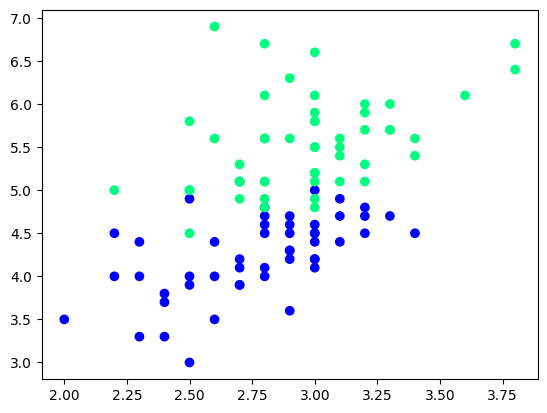

In [54]:
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [55]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal_width,petal_length,species
52,3.1,4.9,1
97,2.9,4.3,1
100,3.3,6.0,2
75,3.0,4.4,1
78,2.9,4.5,1
90,2.6,4.4,1
104,3.0,5.8,2
53,2.3,4.0,1
72,2.5,4.9,1
59,2.7,3.9,1


In [56]:

# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [57]:

df_train

,sepal_width,petal_length,species
80,2.4,3.8,1
59,2.7,3.9,1
69,2.5,3.9,1
58,2.9,4.6,1
60,2.0,3.5,1
56,3.3,4.7,1
131,3.8,6.4,2
96,2.9,4.2,1
141,3.1,5.1,2
95,3.0,4.2,1


In [58]:

df_val

,sepal_width,petal_length,species
146,2.5,5.0,2
66,3.0,4.5,1
140,3.1,5.6,2
100,3.3,6.0,2
98,2.5,3.0,1


In [59]:
df_test

,sepal_width,petal_length,species
87,2.3,4.4,1
111,2.7,5.3,2
65,3.1,4.4,1
57,2.4,3.3,1
52,3.1,4.9,1


In [60]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [61]:
y_test

array([2, 1, 2, 2, 1])

#Case1-Bagging

In [62]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
95,3.0,4.2,1
131,3.8,6.4,2
95,3.0,4.2,1
69,2.5,3.9,1
96,2.9,4.2,1
131,3.8,6.4,2
58,2.9,4.6,1
59,2.7,3.9,1


In [63]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [64]:
dt_bag1 = DecisionTreeClassifier()

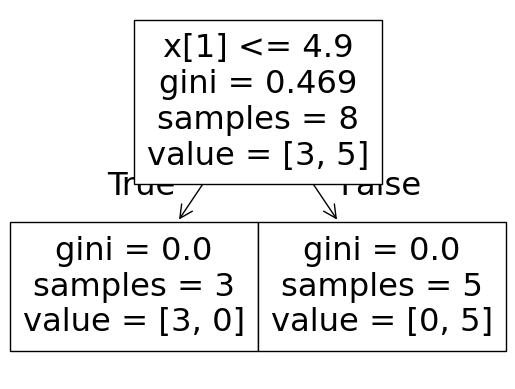

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


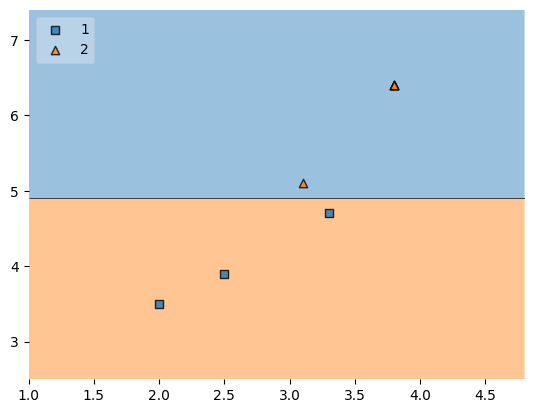

In [72]:
evaluate(dt_bag1,X,y)

In [66]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
131,3.8,6.4,2
56,3.3,4.7,1
60,2.0,3.5,1
69,2.5,3.9,1
131,3.8,6.4,2
131,3.8,6.4,2
141,3.1,5.1,2
131,3.8,6.4,2


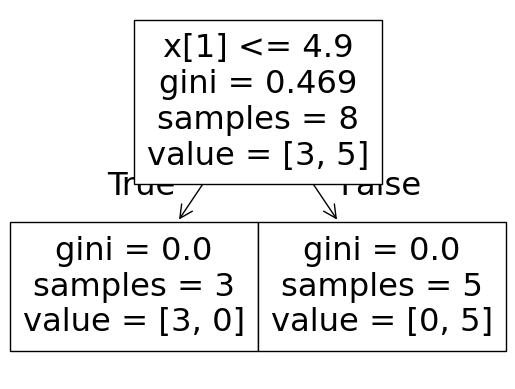

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


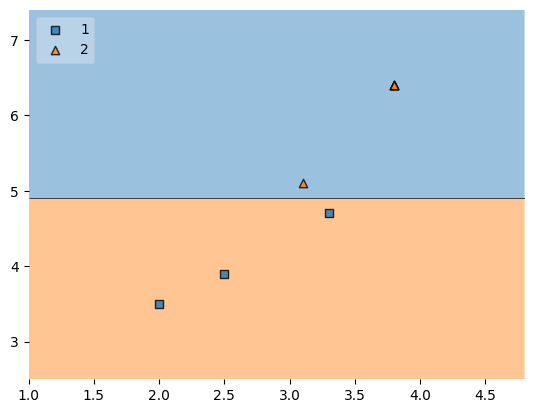

In [71]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

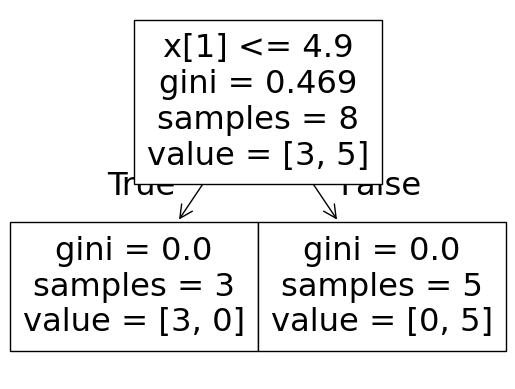

1.0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


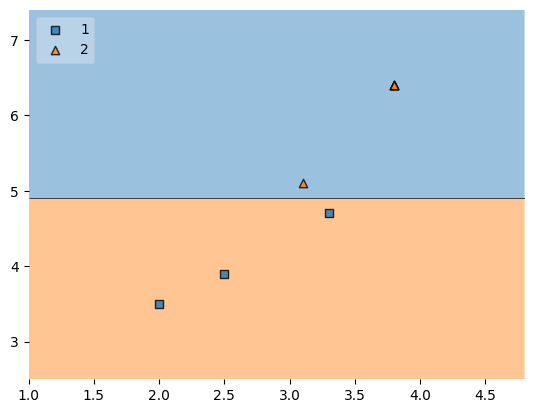

In [73]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

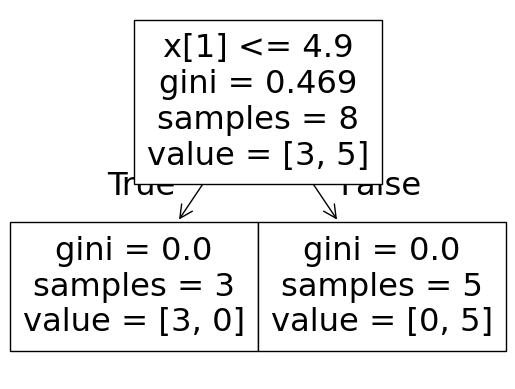

1.0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


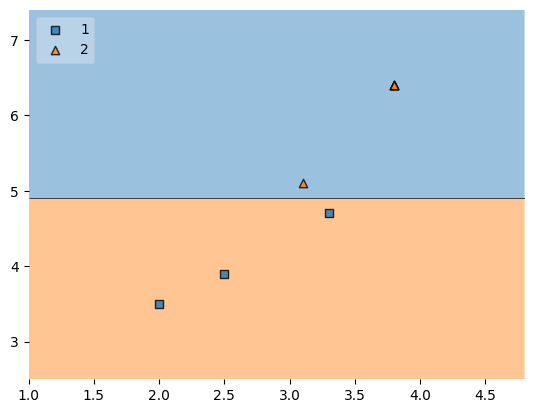

In [74]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [70]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))


#Predict

In [75]:

df_test

,sepal_width,petal_length,species
87,2.3,4.4,1
111,2.7,5.3,2
65,3.1,4.4,1
57,2.4,3.3,1
52,3.1,4.9,1


In [76]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


#Pasting

In [77]:

# Row sampling without replacement
df_train

,sepal_width,petal_length,species
80,2.4,3.8,1
59,2.7,3.9,1
69,2.5,3.9,1
58,2.9,4.6,1
60,2.0,3.5,1
56,3.3,4.7,1
131,3.8,6.4,2
96,2.9,4.2,1
141,3.1,5.1,2
95,3.0,4.2,1


In [78]:
df_train.sample(8)

,sepal_width,petal_length,species
141,3.1,5.1,2
96,2.9,4.2,1
80,2.4,3.8,1
131,3.8,6.4,2
56,3.3,4.7,1
69,2.5,3.9,1
58,2.9,4.6,1
59,2.7,3.9,1


#random subspaces

In [80]:
df1 = pd.read_csv('/content/iris.csv')
df1 = df1.sample(10)

In [81]:
df1.sample(2,replace=True,axis=1)

,sepal_width,species
58,2.9,versicolor
45,3.0,setosa
61,3.0,versicolor
68,2.2,versicolor
7,3.4,setosa
24,3.4,setosa
55,2.8,versicolor
125,3.2,virginica
114,2.8,virginica
128,2.8,virginica


#Random Patches

In [82]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
58,6.6,2.9,4.6,1.3,versicolor
45,4.8,3.0,1.4,0.3,setosa
61,5.9,3.0,4.2,1.5,versicolor
68,6.2,2.2,4.5,1.5,versicolor
7,5.0,3.4,1.5,0.2,setosa
24,4.8,3.4,1.9,0.2,setosa
55,5.7,2.8,4.5,1.3,versicolor
125,7.2,3.2,6.0,1.8,virginica
114,5.8,2.8,5.1,2.4,virginica
128,6.4,2.8,5.6,2.1,virginica


In [83]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,sepal_width,sepal_length
68,2.2,6.2
55,2.8,5.7
68,2.2,6.2
24,3.4,4.8
7,3.4,5.0
68,2.2,6.2
68,2.2,6.2
45,3.0,4.8
